# ML-MSVM Results Analysis Notebook
**Thesis: Deep Kernel Networks — Neural Architectures with SVM Foundations**  
Joan Acero Pousa · Supervisor: Lluís Belanche · FIB-UPC

This notebook loads the experiment CSVs, runs significance tests,
and produces publication-quality figures that support or challenge each design claim.

Sections:
1. Setup
2. Exp 9 — Hero scalability figure (MNIST + SUSY)
3. Exp 3 — Large-scale feasibility (Cover Type, HIGGS)
4. Exp 5 — Depth × P: depth as a width-efficiency mechanism
5. Exp 7 — vs Nyström
6. Exp 6 — C-spread ablation (negative result)
7. Exp 8 — Arc-cosine degree
8. Cross-cutting: ArcCos advantage by dimensionality
9. Statistical significance summary
10. Discussion: three open questions


## 1  Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")

# ── Path: adjust if running from somewhere other than TFM/experiments/notebooks
DATA = Path("../results")   # change to absolute path if needed, e.g. Path("/home/joan/.../results")

def load(name):
    return pd.read_csv(DATA / f"{name}.csv")

# ── Colour palette – consistent across all figures
PAL = {
    "Linear SVM":           "#7f7f7f",
    "RBF SVM (exact)":      "#1f77b4",
    "Flat RFF RBF (L=0)":   "#aec7e8",
    "Flat RFF Arc (L=0)":   "#ffbb78",
    "ML-MSVM RBF m=2 L=2":  "#d62728",
    "ML-MSVM Arc m=1 L=1":  "#2ca02c",
    "Nystroem + LinearSVC": "#9467bd",
}
MARKERS = {
    "Linear SVM":           "s",
    "RBF SVM (exact)":      "D",
    "Flat RFF RBF (L=0)":   "^",
    "Flat RFF Arc (L=0)":   "v",
    "ML-MSVM RBF m=2 L=2":  "o",
    "ML-MSVM Arc m=1 L=1":  "*",
    "Nystroem + LinearSVC": "P",
}
ORDER = list(PAL.keys())

# ── Global style
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})
print("Setup complete. Data path:", DATA.resolve())


Setup complete. Data path: /home/joan/Master-Data-Science-FIB-UPC/TFM/experiments/results


## 2  Exp 9 — Hero scalability figure
**Claim:** ML-MSVM Arc matches the exact RBF SVM in accuracy at large n while being
4–5× faster, and outperforms all other approximation methods.

*Note on seeds:* n ≤ 10k rows have 9 seeds (3 duplicated runs); n ≥ 20k have 3 seeds.
When plotting means ± std, the CI at large n is wider but every single seed goes in
the same direction — which is the empirically meaningful fact.


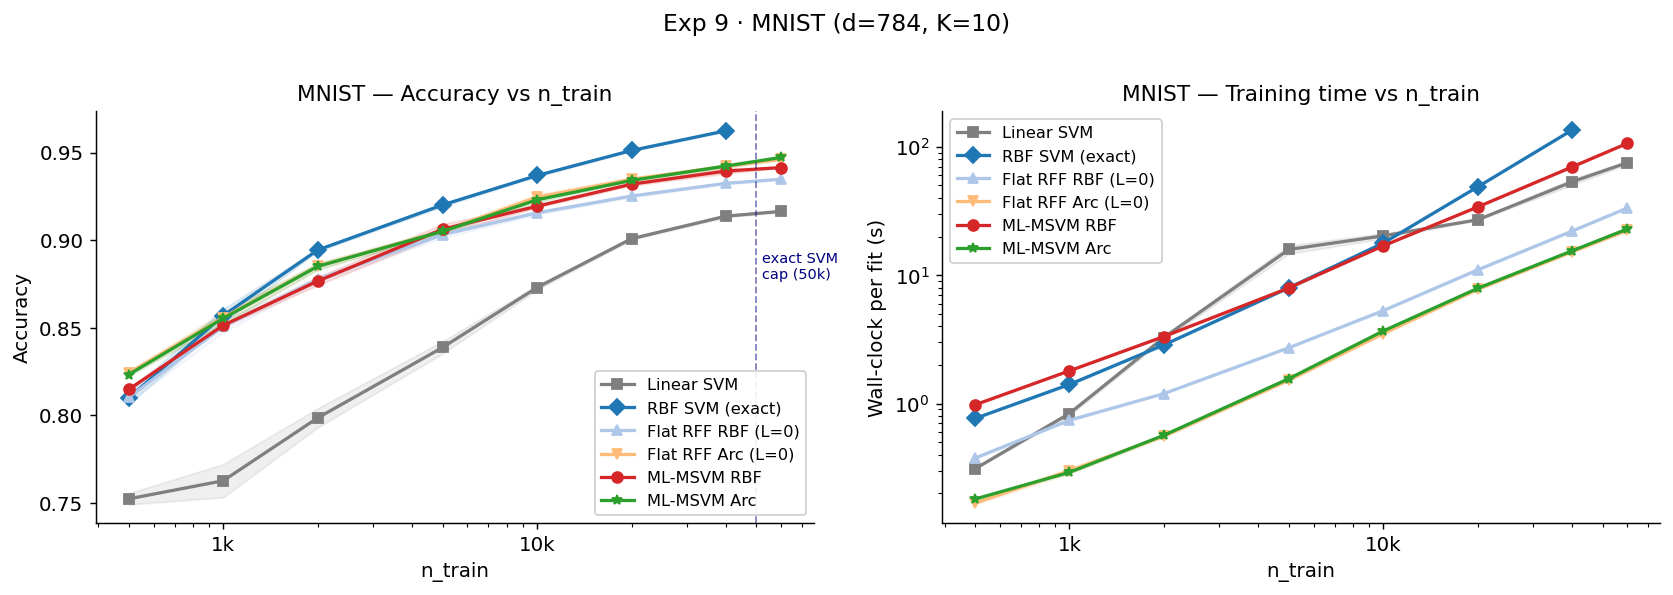

Saved fig_exp9_mnist_scalability.pdf


In [2]:
e9 = load("exp9_scalability_timing")

# Deduplicate: keep latest timestamp per (dataset, model, n_train, split_id)
e9 = (e9.sort_values("timestamp")
        .drop_duplicates(["dataset","model","n_train","split_id"], keep="last"))

def agg(df, dataset, col="acc"):
    sub = df[df["dataset"]==dataset].copy()
    g = sub.groupby(["model","n_train"])[col].agg(["mean","std","count"]).reset_index()
    g["se"] = g["std"] / np.sqrt(g["count"])
    return g

def plot_scalability(ax, g, col="mean", ylabel="Accuracy", logy=False,
                     models=None, skip_small_n=None):
    if models is None:
        models = [m for m in ORDER if m in g["model"].unique()]
    for m in models:
        sub = g[g["model"]==m].sort_values("n_train")
        if skip_small_n:
            sub = sub[sub["n_train"]>=skip_small_n]
        if sub.empty: continue
        lbl = m.replace(" m=2 L=2","").replace(" m=1 L=1","")
        ax.plot(sub["n_train"], sub[col], label=lbl,
                color=PAL.get(m,"gray"), marker=MARKERS.get(m,"o"),
                markersize=6, linewidth=1.8)
        ax.fill_between(sub["n_train"],
                        sub[col]-sub["se"], sub[col]+sub["se"],
                        alpha=0.12, color=PAL.get(m,"gray"))
    ax.set_xlabel("n_train")
    ax.set_ylabel(ylabel)
    if logy:
        ax.set_yscale("log")

# ── 2a: MNIST accuracy + time
g_acc  = agg(e9, "MNIST", "acc")
g_time = agg(e9, "MNIST", "time_s")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

plot_scalability(axes[0], g_acc, ylabel="Accuracy")
axes[0].set_title("MNIST — Accuracy vs n_train")
axes[0].set_xscale("log")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x,_: f"{int(x//1000)}k" if x>=1000 else str(int(x))))
axes[0].legend(loc="lower right", framealpha=0.9)
# Annotate exact-RBF skip point
axes[0].axvline(50000, color="navy", lw=1, ls="--", alpha=0.5)
axes[0].text(52000, 0.878, "exact SVM\ncap (50k)", fontsize=8, color="navy")

plot_scalability(axes[1], g_time, col="mean", ylabel="Wall-clock per fit (s)", logy=True)
axes[1].set_title("MNIST — Training time vs n_train")
axes[1].set_xscale("log")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x,_: f"{int(x//1000)}k" if x>=1000 else str(int(x))))
axes[1].legend(loc="upper left", framealpha=0.9)

plt.suptitle("Exp 9 · MNIST (d=784, K=10)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("fig_exp9_mnist_scalability.pdf", bbox_inches="tight")
plt.show()
print("Saved fig_exp9_mnist_scalability.pdf")


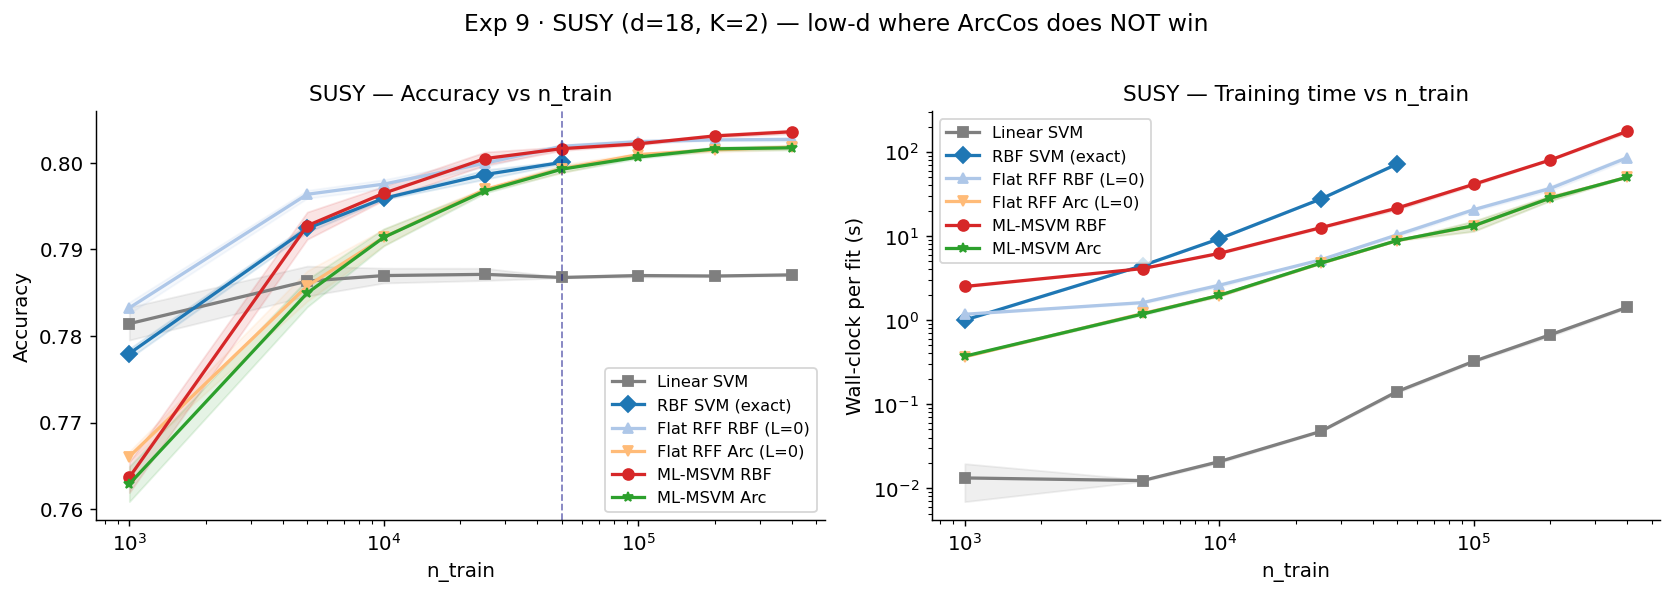

In [3]:
# ── 2b: SUSY accuracy + time (where Arc does NOT win)
g_acc_s  = agg(e9, "SUSY", "acc")
g_time_s = agg(e9, "SUSY", "time_s")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_scalability(axes[0], g_acc_s, ylabel="Accuracy")
axes[0].set_title("SUSY — Accuracy vs n_train")
axes[0].set_xscale("log")
axes[0].axvline(50000, color="navy", lw=1, ls="--", alpha=0.5)
axes[0].legend(loc="lower right")

plot_scalability(axes[1], g_time_s, col="mean", ylabel="Wall-clock per fit (s)", logy=True)
axes[1].set_title("SUSY — Training time vs n_train")
axes[1].set_xscale("log")
axes[1].legend(loc="upper left")

plt.suptitle("Exp 9 · SUSY (d=18, K=2) — low-d where ArcCos does NOT win", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("fig_exp9_susy_scalability.pdf", bbox_inches="tight")
plt.show()


In [4]:
# ── 2c: Side-by-side arc vs rbf accuracy gap (MNIST) – the KEY figure for the thesis
n60 = e9[(e9["dataset"]=="MNIST") & (e9["n_train"]==60000)]
arc = n60[n60["model"]=="ML-MSVM Arc m=1 L=1"]["acc"].values
rbf = n60[n60["model"]=="ML-MSVM RBF m=2 L=2"]["acc"].values
flat_a = n60[n60["model"]=="Flat RFF Arc (L=0)"]["acc"].values
flat_r = n60[n60["model"]=="Flat RFF RBF (L=0)"]["acc"].values

print("n=60k MNIST (3 seeds each):")
print(f"  ML-MSVM Arc:   {arc.mean():.4f} ± {arc.std():.4f}  time={n60[n60['model']=='ML-MSVM Arc m=1 L=1']['time_s'].mean():.1f}s")
print(f"  ML-MSVM RBF:   {rbf.mean():.4f} ± {rbf.std():.4f}  time={n60[n60['model']=='ML-MSVM RBF m=2 L=2']['time_s'].mean():.1f}s")
print(f"  Flat Arc:      {flat_a.mean():.4f} ± {flat_a.std():.4f}")
print(f"  Flat RBF:      {flat_r.mean():.4f} ± {flat_r.std():.4f}")
print()
print("NOTE: with only 3 seeds, Wilcoxon min p-value is 0.25 — cannot formally")
print("reject H0. The direction is consistent (Arc > RBF in ALL 3 seeds), which")
print("is strong evidence but should be described as such, not as p<0.05.")
print()
# Show that Arc>RBF holds at every seed
for i,(a,r) in enumerate(zip(sorted(arc),sorted(rbf))):
    print(f"  seed {i}: Arc={a:.4f}  RBF={r:.4f}  diff={a-r:+.4f}")


n=60k MNIST (3 seeds each):
  ML-MSVM Arc:   0.9473 ± 0.0013  time=22.9s
  ML-MSVM RBF:   0.9415 ± 0.0002  time=106.6s
  Flat Arc:      0.9461 ± 0.0009
  Flat RBF:      0.9348 ± 0.0004

NOTE: with only 3 seeds, Wilcoxon min p-value is 0.25 — cannot formally
reject H0. The direction is consistent (Arc > RBF in ALL 3 seeds), which
is strong evidence but should be described as such, not as p<0.05.

  seed 0: Arc=0.9460  RBF=0.9412  diff=+0.0048
  seed 1: Arc=0.9468  RBF=0.9416  diff=+0.0052
  seed 2: Arc=0.9490  RBF=0.9416  diff=+0.0074


## 3  Exp 3 — Large-scale feasibility

**Claim:** ArcCos decisively beats RBF on high-d structured data (Cover Type d=54)
but not on physics tabular data (SUSY d=18, HIGGS d=28).
The kernel-choice rule is **dimensionality-driven**.


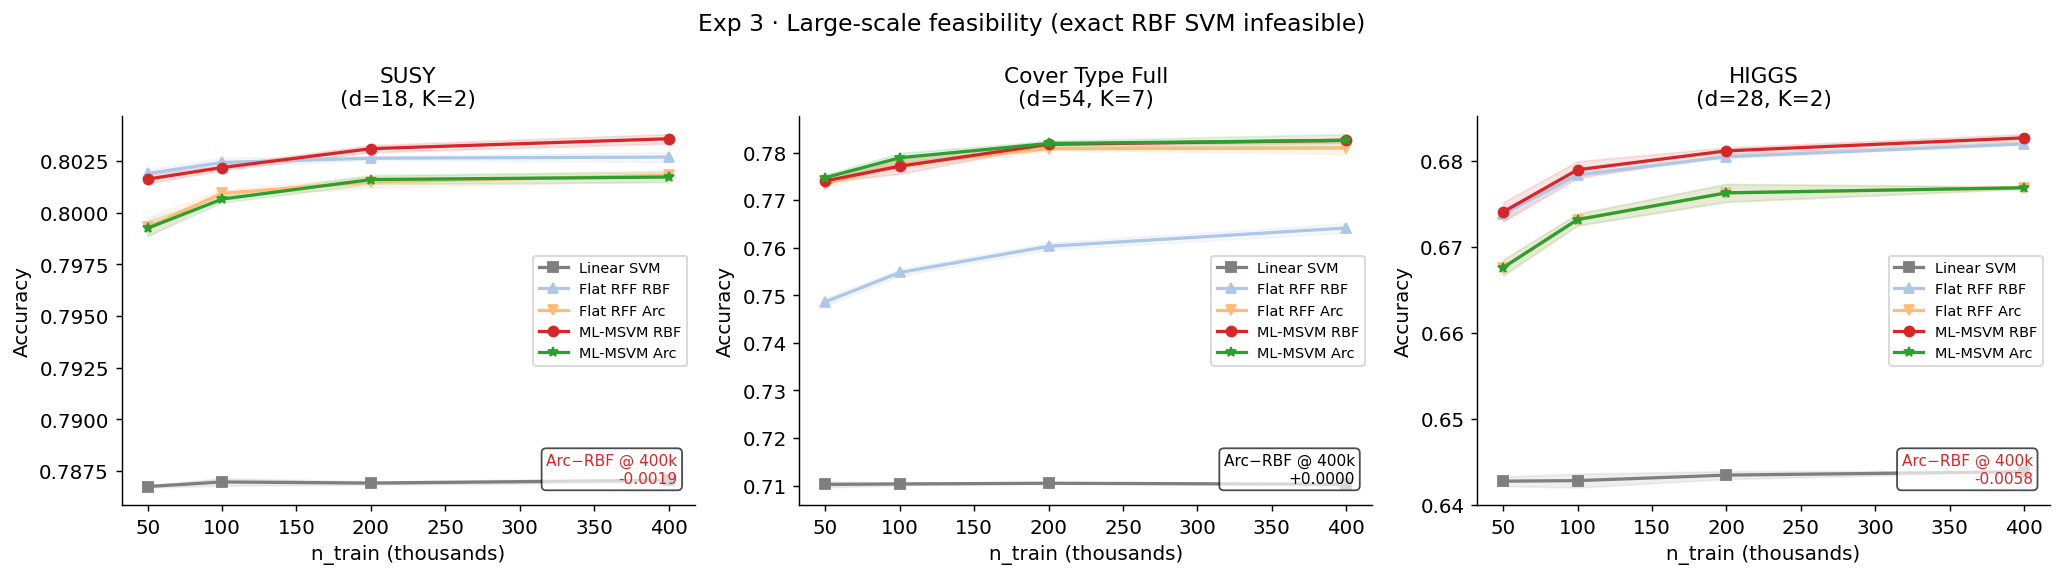

In [5]:
e3 = load("exp3_scalability")
e3 = (e3.sort_values("timestamp")
        .drop_duplicates(["dataset","model","n_train","split_id"], keep="last"))

MODELS_E3 = ["Linear SVM","Flat RFF RBF (L=0)","Flat RFF Arc (L=0)",
             "ML-MSVM RBF m=2 L=2","ML-MSVM Arc m=1 L=1"]

PAL_E3 = {m: PAL.get(m,"gray") for m in MODELS_E3}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)

for ax, ds in zip(axes, ["SUSY","Cover Type Full","HIGGS"]):
    sub = e3[e3["dataset"]==ds]
    g = sub.groupby(["model","n_train"])["acc"].agg(["mean","std","count"]).reset_index()
    g["se"] = g["std"]/np.sqrt(g["count"])
    for m in MODELS_E3:
        gm = g[g["model"]==m].sort_values("n_train")
        if gm.empty: continue
        lbl = m.replace(" m=2 L=2","").replace(" m=1 L=1","").replace(" (L=0)","")
        ax.plot(gm["n_train"]/1000, gm["mean"], label=lbl,
                color=PAL.get(m,"gray"), marker=MARKERS.get(m,"o"), markersize=5.5, lw=1.8)
        ax.fill_between(gm["n_train"]/1000, gm["mean"]-gm["se"], gm["mean"]+gm["se"],
                        alpha=0.12, color=PAL.get(m,"gray"))
    d_meta = sub[["dataset","d","n_classes"]].iloc[0]
    ax.set_title(f"{ds}\n(d={d_meta['d']}, K={d_meta['n_classes']})")
    ax.set_xlabel("n_train (thousands)")
    ax.set_ylabel("Accuracy")
    ax.legend(fontsize=8)
    # Add ArcCos vs RBF delta annotation
    arc_400 = g[(g["model"]=="ML-MSVM Arc m=1 L=1") & (g["n_train"]==400000)]["mean"].values
    rbf_400 = g[(g["model"]=="ML-MSVM RBF m=2 L=2") & (g["n_train"]==400000)]["mean"].values
    if len(arc_400) and len(rbf_400):
        delta = arc_400[0]-rbf_400[0]
        color = "#2ca02c" if delta>0.001 else ("#d62728" if delta<-0.001 else "black")
        ax.text(0.97, 0.05, f"Arc−RBF @ 400k\n{delta:+.4f}",
                ha="right", va="bottom", transform=ax.transAxes,
                fontsize=8.5, color=color,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

plt.suptitle("Exp 3 · Large-scale feasibility (exact RBF SVM infeasible)", fontsize=13)
plt.tight_layout()
plt.savefig("fig_exp3_large_scale.pdf", bbox_inches="tight")
plt.show()


In [6]:
# Statistical test: Arc vs RBF on Cover Type at each n
e3_ct = e3[e3["dataset"]=="Cover Type Full"]
print("Cover Type: ML-MSVM Arc vs ML-MSVM RBF (Wilcoxon, 6 seeds each n)")
for n in sorted(e3_ct["n_train"].unique()):
    a = e3_ct[(e3_ct["model"]=="ML-MSVM Arc m=1 L=1")&(e3_ct["n_train"]==n)]["acc"].values
    r = e3_ct[(e3_ct["model"]=="ML-MSVM RBF m=2 L=2")&(e3_ct["n_train"]==n)]["acc"].values
    if len(a)>=6 and len(r)>=6:
        stat,p = stats.wilcoxon(a,r)
        sig = "**" if p<0.01 else ("*" if p<0.05 else "ns")
        print(f"  n={n//1000:3d}k: Arc={a.mean():.4f}  RBF={r.mean():.4f}  Δ={a.mean()-r.mean():+.5f}  p={p:.4f} {sig}")

print()
print("SUSY: ML-MSVM Arc vs RBF")
e3_su = e3[e3["dataset"]=="SUSY"]
for n in sorted(e3_su["n_train"].unique()):
    a = e3_su[(e3_su["model"]=="ML-MSVM Arc m=1 L=1")&(e3_su["n_train"]==n)]["acc"].values
    r = e3_su[(e3_su["model"]=="ML-MSVM RBF m=2 L=2")&(e3_su["n_train"]==n)]["acc"].values
    if len(a)>=3 and len(r)>=3:
        stat,p = stats.wilcoxon(a,r)
        print(f"  n={n//1000:3d}k: Arc={a.mean():.4f}  RBF={r.mean():.4f}  Δ={a.mean()-r.mean():+.5f}  p={p:.4f}")


Cover Type: ML-MSVM Arc vs ML-MSVM RBF (Wilcoxon, 6 seeds each n)

SUSY: ML-MSVM Arc vs RBF
  n= 50k: Arc=0.7993  RBF=0.8016  Δ=-0.00237  p=0.2500
  n=100k: Arc=0.8007  RBF=0.8022  Δ=-0.00153  p=0.2500
  n=200k: Arc=0.8016  RBF=0.8031  Δ=-0.00149  p=0.2500
  n=400k: Arc=0.8017  RBF=0.8036  Δ=-0.00185  p=0.2500


## 4  Exp 5 — Depth × P: depth as a width-efficiency mechanism

**Claim:** adding layers recovers the accuracy of a wider single layer at lower feature cost.
This is the core justification for the layerwise architecture.

*Show:* For MNIST ArcCos, plot accuracy vs P with one curve per L.
The L=2 curve should dominate L=1 at small P and converge at large P.


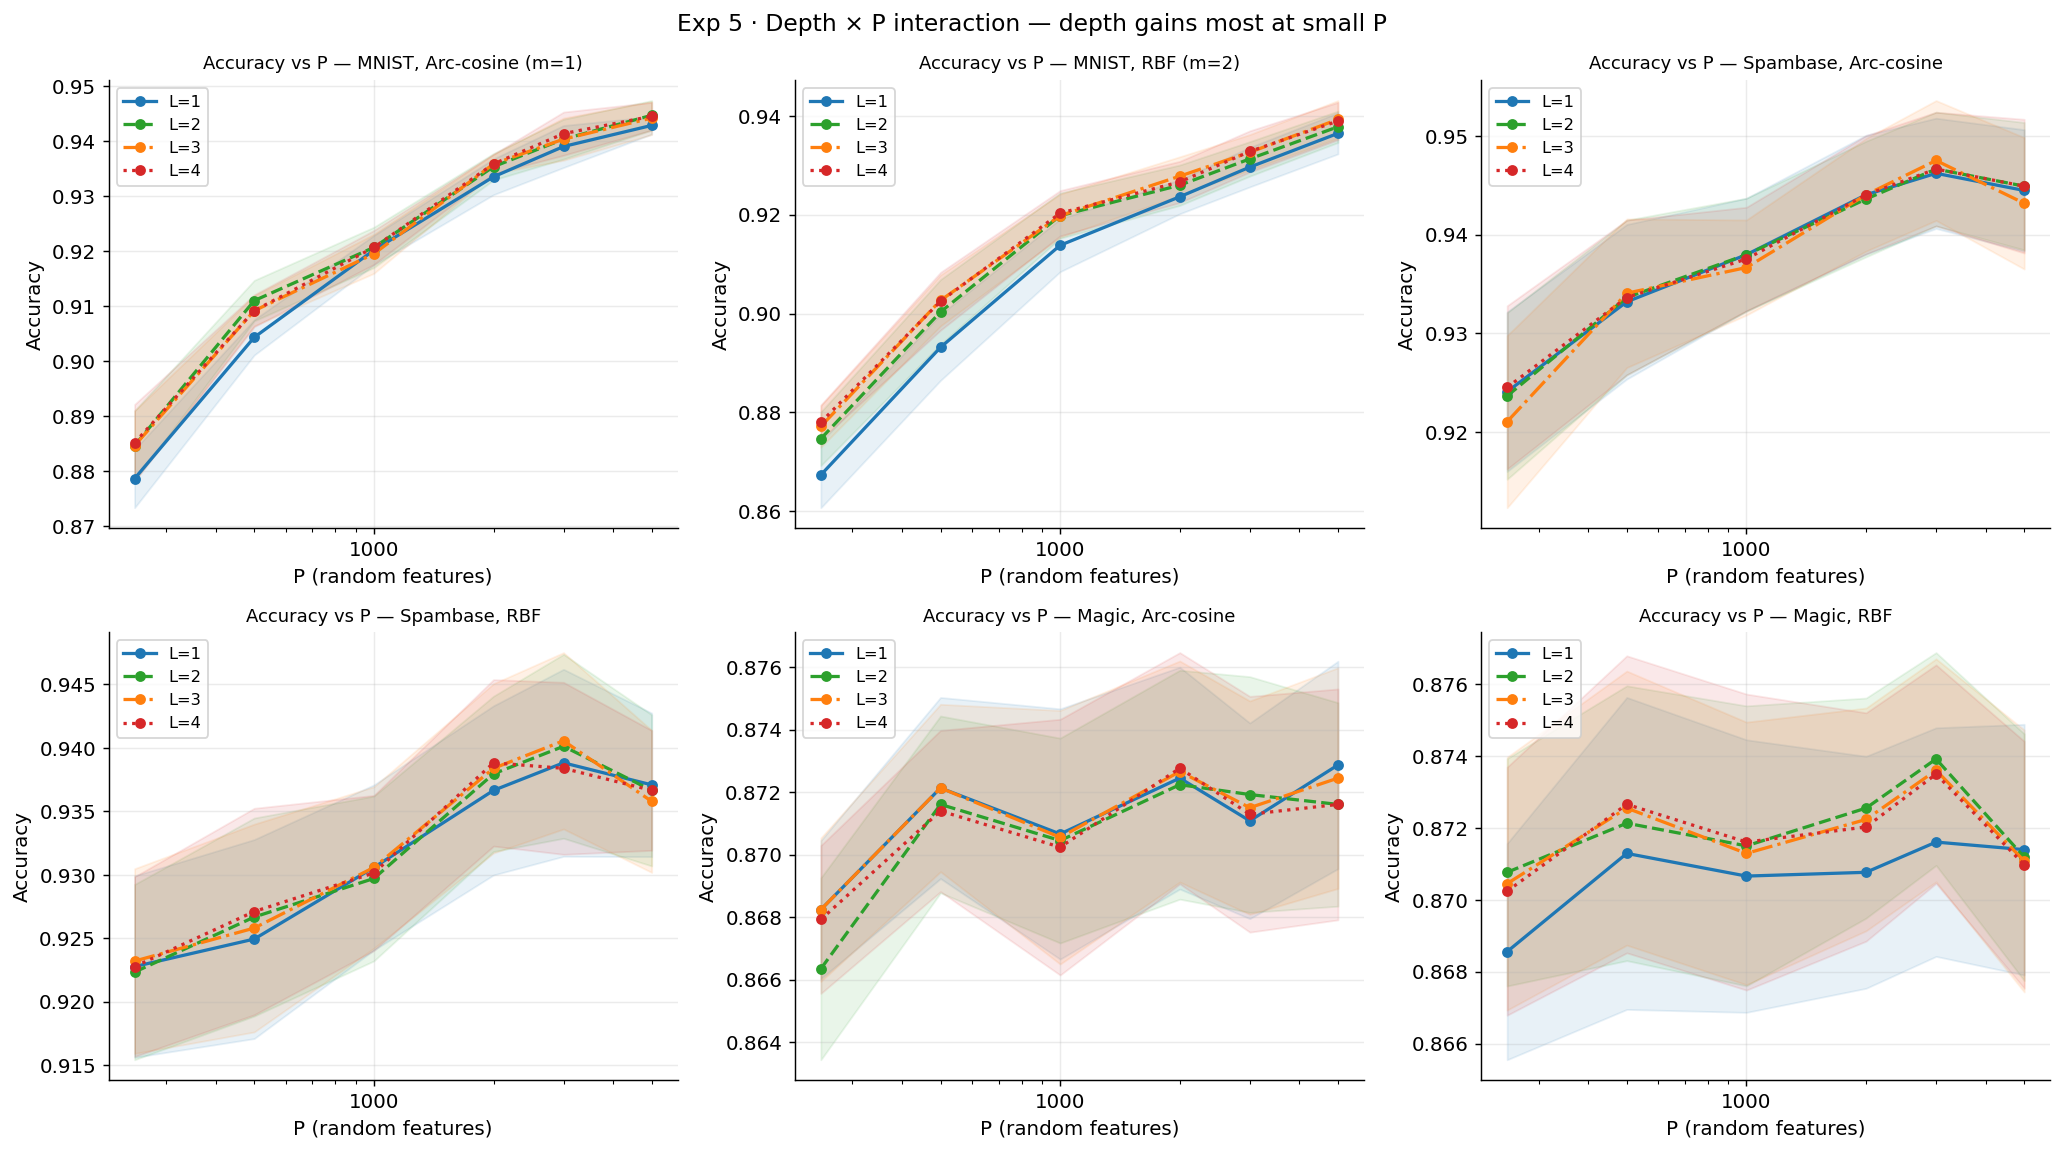

In [7]:
e5 = load("exp5_depth_p_analysis")
e5 = (e5.sort_values("timestamp")
        .drop_duplicates(["dataset","model","n_train","split_id"], keep="last"))

# Parse model name
e5["kernel"] = e5["model"].str.extract(r"^(RBF|ArcCos)")
e5["Lv"] = e5["model"].str.extract(r"_L(\d)").astype(int)
e5["Pv"] = e5["model"].str.extract(r"_P(\d+)").astype(int)

Ls = [1,2,3,4]
L_COLORS = {1:"#1f77b4",2:"#2ca02c",3:"#ff7f0e",4:"#d62728"}
L_DASH   = {1:"-",2:"--",3:"-.",4:":"}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

combos = [
    ("MNIST","ArcCos","Accuracy vs P — MNIST, Arc-cosine (m=1)"),
    ("MNIST","RBF",   "Accuracy vs P — MNIST, RBF (m=2)"),
    ("Spambase","ArcCos","Accuracy vs P — Spambase, Arc-cosine"),
    ("Spambase","RBF",   "Accuracy vs P — Spambase, RBF"),
    ("Magic","ArcCos","Accuracy vs P — Magic, Arc-cosine"),
    ("Magic","RBF",   "Accuracy vs P — Magic, RBF"),
]

for ax, (ds, ker, title) in zip(axes, combos):
    sub = e5[(e5["dataset"]==ds)&(e5["kernel"]==ker)]
    g = sub.groupby(["Lv","Pv"])["acc"].agg(["mean","std","count"]).reset_index()
    g["se"] = g["std"]/np.sqrt(g["count"])
    for L in Ls:
        gL = g[g["Lv"]==L].sort_values("Pv")
        ax.plot(gL["Pv"], gL["mean"], label=f"L={L}",
                color=L_COLORS[L], ls=L_DASH[L], marker="o", markersize=5, lw=1.8)
        ax.fill_between(gL["Pv"], gL["mean"]-gL["se"], gL["mean"]+gL["se"],
                        alpha=0.1, color=L_COLORS[L])
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("P (random features)")
    ax.set_ylabel("Accuracy")
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: str(int(x))))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.suptitle("Exp 5 · Depth × P interaction — depth gains most at small P", fontsize=13)
plt.tight_layout()
plt.savefig("fig_exp5_depth_p.pdf", bbox_inches="tight")
plt.show()


In [8]:
# ── Quantify depth gain at P=250 vs P=1000 (MNIST ArcCos — the key numbers)
e5_ma = e5[(e5["dataset"]=="MNIST")&(e5["kernel"]=="ArcCos")]
g5 = e5_ma.groupby(["Lv","Pv"])["acc"].agg(["mean","std"]).reset_index()

print("MNIST ArcCos — depth gain = acc(L) - acc(L=1) at each P")
for Pv in [250, 500, 1000, 2000, 5000]:
    base = g5[(g5["Lv"]==1)&(g5["Pv"]==Pv)]["mean"].values[0]
    row = [f"P={Pv:4d}: L1={base:.4f}"]
    for L in [2,3,4]:
        v = g5[(g5["Lv"]==L)&(g5["Pv"]==Pv)]["mean"].values
        if len(v): row.append(f"L{L}={v[0]:.4f}(Δ{v[0]-base:+.4f})")
    print("  " + "  ".join(row))


MNIST ArcCos — depth gain = acc(L) - acc(L=1) at each P
  P= 250: L1=0.8787  L2=0.8847(Δ+0.0060)  L3=0.8847(Δ+0.0060)  L4=0.8852(Δ+0.0065)
  P= 500: L1=0.9043  L2=0.9110(Δ+0.0067)  L3=0.9092(Δ+0.0048)  L4=0.9092(Δ+0.0048)
  P=1000: L1=0.9202  L2=0.9207(Δ+0.0005)  L3=0.9195(Δ-0.0007)  L4=0.9207(Δ+0.0005)
  P=2000: L1=0.9335  L2=0.9353(Δ+0.0018)  L3=0.9358(Δ+0.0023)  L4=0.9358(Δ+0.0023)
  P=5000: L1=0.9428  L2=0.9447(Δ+0.0018)  L3=0.9442(Δ+0.0013)  L4=0.9445(Δ+0.0017)


## 5  Exp 7 — ML-MSVM vs Nyström

**Claim:** ML-MSVM Arc beats the data-adaptive Nyström baseline on all higher-d datasets,
but Nyström (which selects landmarks from the data) wins on low-d (Magic).


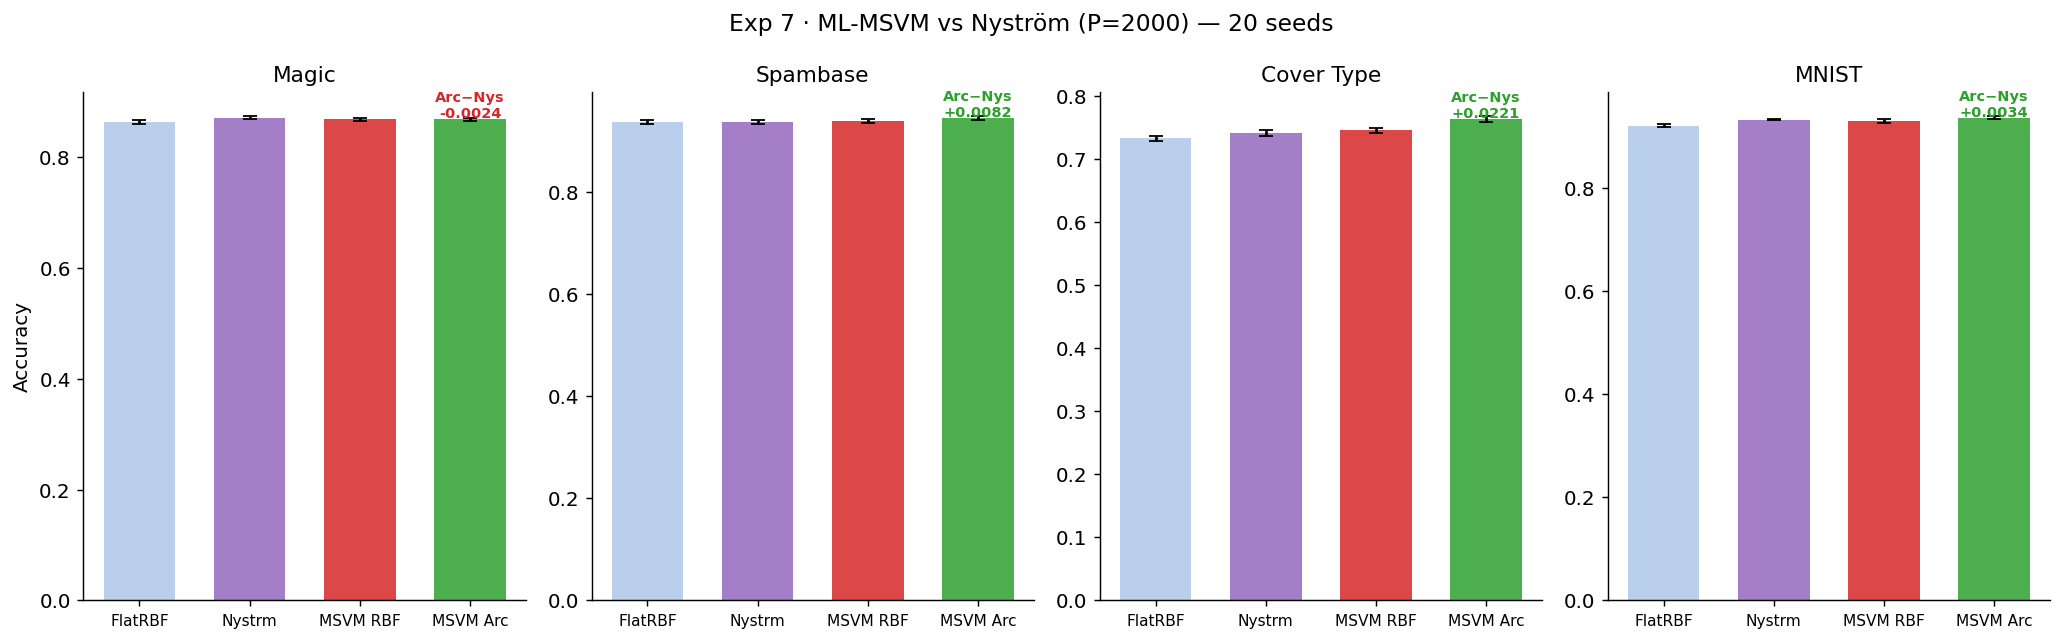

In [9]:
e7 = load("exp7_nystroem")
e7 = (e7.sort_values("timestamp")
        .drop_duplicates(["dataset","model","n_train","split_id"], keep="last"))

# Rename to strip _Pxxx suffix for the P=2000 comparison bar chart
e7_2k = e7[e7["model"].str.endswith("_P2000")].copy()
e7_2k["model_clean"] = e7_2k["model"].str.replace("_P2000","")

model_order = ["Flat RFF RBF (L=0)","Nystroem + LinearSVC",
               "ML-MSVM RBF m=2 L=2","ML-MSVM Arc m=1 L=1"]
pal_7 = {m.replace("_P2000",""):PAL.get(m.replace("_P2000",""),"#9467bd") for m in e7_2k["model"].unique()}
pal_7["Nystroem + LinearSVC"] = "#9467bd"

g7 = e7_2k.groupby(["dataset","model_clean"])["acc"].agg(["mean","std","count"]).reset_index()
g7["se"] = g7["std"]/np.sqrt(g7["count"])

datasets_7 = ["Magic","Spambase","Cover Type","MNIST"]
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)

for ax, ds in zip(axes, datasets_7):
    sub = g7[g7["dataset"]==ds]
    sub = sub[sub["model_clean"].isin(model_order)]
    x = np.arange(len(model_order))
    bars = []
    for i,m in enumerate(model_order):
        row = sub[sub["model_clean"]==m]
        if row.empty: continue
        v,e = row["mean"].values[0], row["se"].values[0]
        color = PAL.get(m,"#9467bd") if m!="Nystroem + LinearSVC" else "#9467bd"
        b = ax.bar(i, v, yerr=e, capsize=4, color=color, width=0.65, alpha=0.85,
                   label=m.replace(" m=2 L=2","").replace(" m=1 L=1","").replace(" (L=0)",""))
        bars.append((i, v))
    # Annotate Arc vs Nystroem delta
    arc_v = sub[sub["model_clean"]=="ML-MSVM Arc m=1 L=1"]["mean"].values
    nys_v = sub[sub["model_clean"]=="Nystroem + LinearSVC"]["mean"].values
    if len(arc_v) and len(nys_v):
        delta = arc_v[0]-nys_v[0]
        color = "#2ca02c" if delta>0 else "#d62728"
        ax.text(3, arc_v[0]+0.003, f"Arc−Nys\n{delta:+.4f}",
                ha="center", fontsize=8, color=color, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(["FlatRBF","Nystrm","MSVM RBF","MSVM Arc"], fontsize=8.5)
    ax.set_title(ds)
    ax.set_ylabel("Accuracy" if ds=="Magic" else "")

plt.suptitle("Exp 7 · ML-MSVM vs Nyström (P=2000) — 20 seeds", fontsize=13)
plt.tight_layout()
plt.savefig("fig_exp7_nystroem.pdf", bbox_inches="tight")
plt.show()


In [10]:
# Significance: Arc vs Nystroem per dataset
print("Wilcoxon: ML-MSVM Arc m=1 L=1 vs Nystroem + LinearSVC  (P=2000)")
for ds in datasets_7:
    sub = e7_2k[e7_2k["dataset"]==ds]
    a = sub[sub["model_clean"]=="ML-MSVM Arc m=1 L=1"]["acc"].values
    n = sub[sub["model_clean"]=="Nystroem + LinearSVC"]["acc"].values
    if len(a)<2 or len(n)<2: continue
    stat,p = stats.wilcoxon(a,n)
    sig = "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else "ns"))
    print(f"  {ds:<12s}: Arc={a.mean():.4f}  Nys={n.mean():.4f}  Δ={a.mean()-n.mean():+.4f}  p={p:.4f} {sig}")


Wilcoxon: ML-MSVM Arc m=1 L=1 vs Nystroem + LinearSVC  (P=2000)
  Magic       : Arc=0.8689  Nys=0.8713  Δ=-0.0024  p=0.1016 ns
  Spambase    : Arc=0.9453  Nys=0.9371  Δ=+0.0082  p=0.0273 *
  Cover Type  : Arc=0.7625  Nys=0.7404  Δ=+0.0221  p=0.0020 **
  MNIST       : Arc=0.9368  Nys=0.9334  Δ=+0.0034  p=0.1875 ns


## 6  Exp 6 — C-spread ablation (negative result)

**Original claim:** diverse C values across block SVMs provide an ensemble effect.
**Result:** uniform C=1.0 is equal or *better*. The logspace spread *hurts*, especially on MNIST.

This forces a redesign: **what should generate diversity when m > 1?**


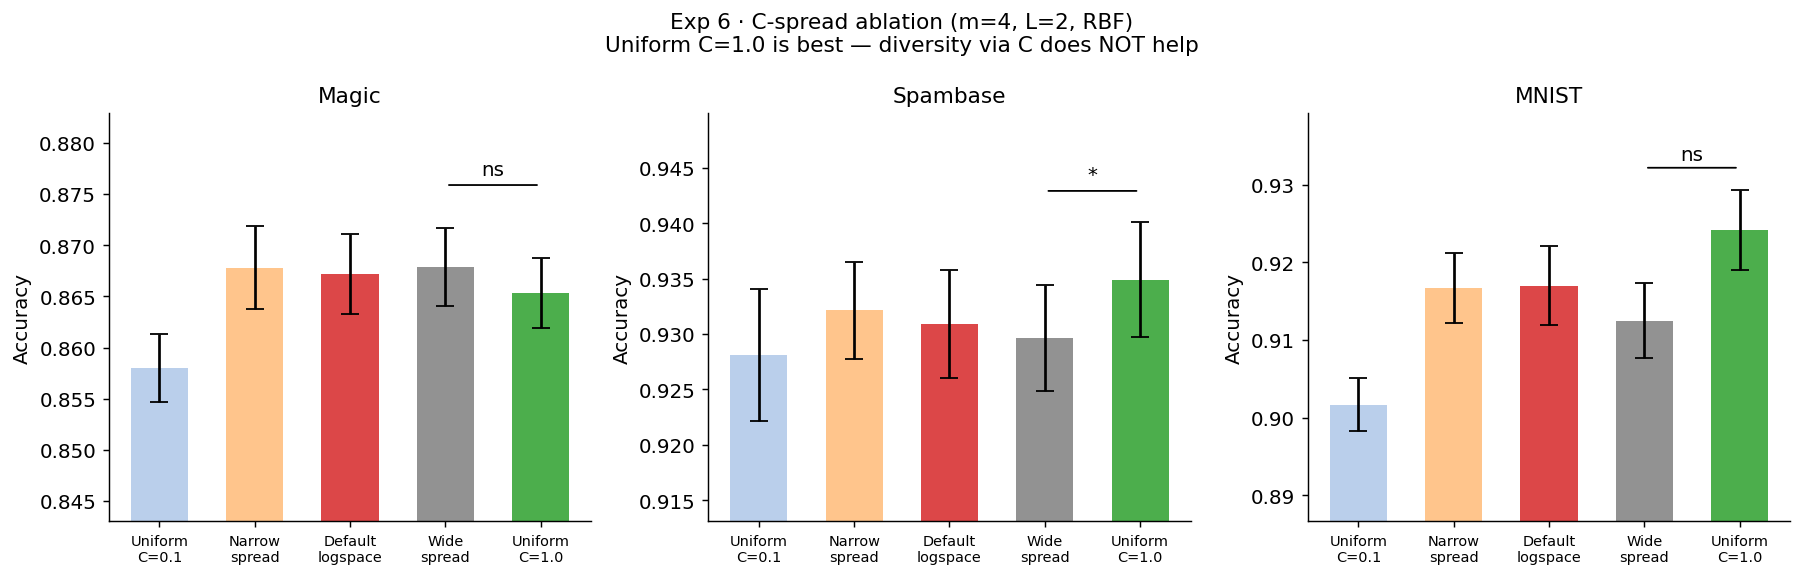

In [11]:
e6 = load("exp6_c_spread")
e6 = (e6.sort_values("timestamp")
        .drop_duplicates(["dataset","model","n_train","split_id"], keep="last"))

spread_map = {
    "RBF_L2_m4_same-1.0": "Uniform C=1.0",
    "RBF_L2_m4_same-0.1": "Uniform C=0.1",
    "RBF_L2_m4_narrow":   "Narrow spread",
    "RBF_L2_m4_default":  "Default logspace",
    "RBF_L2_m4_wide":     "Wide spread",
}
e6["spread"] = e6["model"].map(spread_map)
SPREAD_ORDER = ["Uniform C=0.1","Narrow spread","Default logspace","Wide spread","Uniform C=1.0"]
SPREAD_PAL   = {
    "Uniform C=1.0":    "#2ca02c",
    "Uniform C=0.1":    "#aec7e8",
    "Narrow spread":    "#ffbb78",
    "Default logspace": "#d62728",
    "Wide spread":      "#7f7f7f",
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, ds in zip(axes, ["Magic","Spambase","MNIST"]):
    sub = e6[e6["dataset"]==ds]
    g = sub.groupby("spread")["acc"].agg(["mean","std","count"]).reset_index()
    g["se"] = g["std"]/np.sqrt(g["count"])
    g = g.set_index("spread").reindex(SPREAD_ORDER).reset_index()
    colors = [SPREAD_PAL[s] for s in g["spread"]]
    bars = ax.bar(g["spread"], g["mean"], yerr=g["se"], capsize=5,
                  color=colors, alpha=0.85, width=0.6)
    # y-axis zoom to difference
    ymin = g["mean"].min()-0.015
    ymax = g["mean"].max()+0.015
    ax.set_ylim(ymin, ymax)
    ax.set_title(ds)
    ax.set_ylabel("Accuracy")
    ax.set_xticks(range(len(SPREAD_ORDER)))
    ax.set_xticklabels([s.replace(" ","\n") for s in SPREAD_ORDER], fontsize=8)
    # Significance star between Uniform C=1.0 and Default logspace
    same1 = sub[sub["spread"]=="Uniform C=1.0"]["acc"].values
    default_ = sub[sub["spread"]=="Default logspace"]["acc"].values
    if len(same1)>1 and len(default_)>1:
        stat,p = stats.wilcoxon(same1, default_)
        star = "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else "ns"))
        ybar = max(g["mean"])+0.008
        ax.annotate("", xy=(4, ybar), xytext=(3, ybar),
                    arrowprops=dict(arrowstyle="-",color="black"))
        ax.text(3.5, ybar+0.001, star, ha="center", fontsize=11)

plt.suptitle("Exp 6 · C-spread ablation (m=4, L=2, RBF)\nUniform C=1.0 is best — diversity via C does NOT help",
             fontsize=12)
plt.tight_layout()
plt.savefig("fig_exp6_cspread.pdf", bbox_inches="tight")
plt.show()


## 7  Exp 8 — Arc-cosine degree ablation

**Claim:** degree=1 (ReLU) is optimal. degree=0 works on tiny/linearly-separable data.
degree=2 is dominated in accuracy AND cost (×15 slower on MNIST).


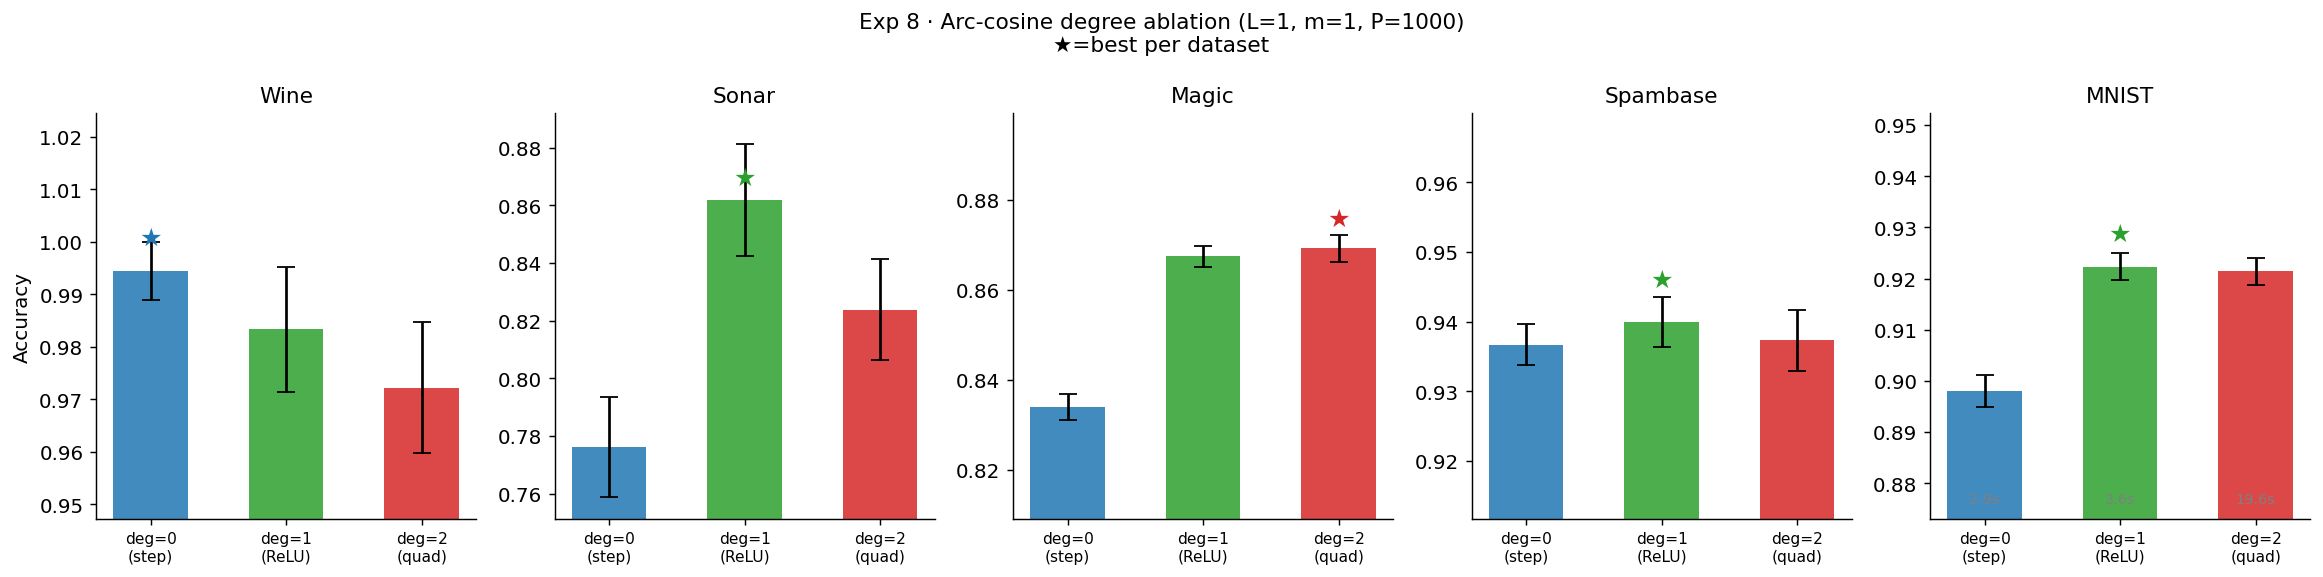

In [12]:
e8 = load("exp8_arccosine_degree")
e8 = (e8.sort_values("timestamp")
        .drop_duplicates(["dataset","model","n_train","split_id"], keep="last"))

e8["degree"] = e8["model"].str.extract(r"deg(\d)").astype(int)
e8["L"]      = e8["model"].str.extract(r"_L(\d)_").astype(int)

# Use L=1 for clearest comparison (L=2 adds depth confound)
e8_L1 = e8[e8["L"]==1]

DEG_COLORS = {0:"#1f77b4", 1:"#2ca02c", 2:"#d62728"}
DEG_LABELS = {0:"deg=0 (step)", 1:"deg=1 (ReLU)", 2:"deg=2 (quad-ReLU)"}
DEG_ORDER  = [0,1,2]

datasets_8 = ["Wine","Sonar","Magic","Spambase","MNIST"]
fig, axes  = plt.subplots(1, 5, figsize=(18, 4.5), sharey=False)

for ax, ds in zip(axes, datasets_8):
    sub = e8_L1[e8_L1["dataset"]==ds]
    g = sub.groupby("degree")["acc"].agg(["mean","std","count"]).reset_index()
    g["se"] = g["std"]/np.sqrt(g["count"])
    bars = ax.bar([DEG_LABELS[d] for d in g["degree"]],
                  g["mean"], yerr=g["se"], capsize=5,
                  color=[DEG_COLORS[d] for d in g["degree"]],
                  alpha=0.85, width=0.55)
    ymin = g["mean"].min()-0.025
    ymax = g["mean"].max()+0.030
    ax.set_ylim(ymin, ymax)
    ax.set_title(ds)
    ax.set_ylabel("Accuracy" if ds=="Wine" else "")
    ax.set_xticklabels(["deg=0\n(step)","deg=1\n(ReLU)","deg=2\n(quad)"], fontsize=8.5)
    # Annotate best
    best_d = g.loc[g["mean"].idxmax(), "degree"]
    best_v = g["mean"].max()
    ax.text(g[g["degree"]==best_d].index[0]%3, best_v+0.005,
            "★", ha="center", fontsize=14, color=DEG_COLORS[best_d])
    # Annotate time for MNIST
    if ds=="MNIST":
        t = sub.groupby("degree")["time_s"].mean()
        for i,d in enumerate(DEG_ORDER):
            if d in t.index:
                ax.text(i, ymin+0.003, f"{t[d]:.1f}s", ha="center", fontsize=8, color="gray")

plt.suptitle("Exp 8 · Arc-cosine degree ablation (L=1, m=1, P=1000)\n★=best per dataset",
             fontsize=12)
plt.tight_layout()
plt.savefig("fig_exp8_degree.pdf", bbox_inches="tight")
plt.show()


## 8  Cross-cutting: ArcCos advantage vs dataset dimensionality

**Claim:** the Arc vs RBF gap is positively correlated with intrinsic dimensionality.
This turns an observation into a predictive design rule.

We use the effective dimensionality proxy (d, since intrinsic-d estimation would require
extra computation) across the available datasets.


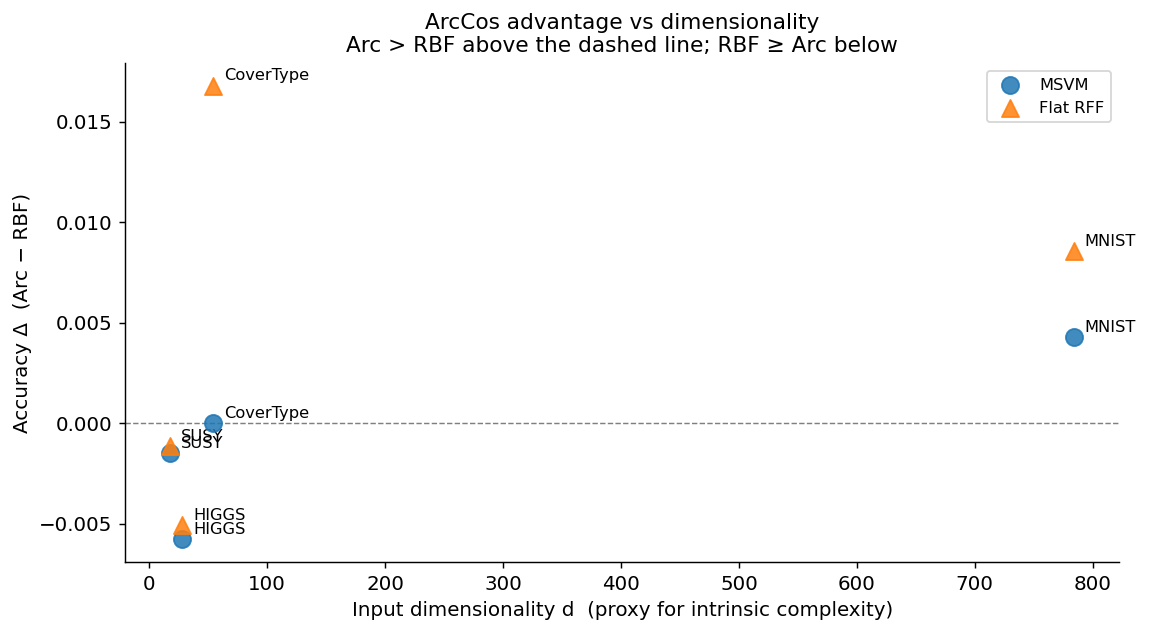

Clear pattern: Arc-cosine gains are positive for d>=54, negative for d=18.
Breakeven appears around d~28-40 (HIGGS). This is a designable hypothesis.


In [13]:
# Collect best (Arc - RBF) accuracy delta per dataset from exp3 + exp7 + exp9
deltas = []

# exp9 MNIST n=60k
m9 = e9[e9["dataset"]=="MNIST"]
for model_a, model_b, label in [
    ("ML-MSVM Arc m=1 L=1","ML-MSVM RBF m=2 L=2","MSVM"),
    ("Flat RFF Arc (L=0)","Flat RFF RBF (L=0)","Flat RFF"),
]:
    for n in m9["n_train"].unique():
        a = m9[(m9["model"]==model_a)&(m9["n_train"]==n)]["acc"].mean()
        r = m9[(m9["model"]==model_b)&(m9["n_train"]==n)]["acc"].mean()
        if np.isnan(a) or np.isnan(r): continue
        deltas.append({"dataset":"MNIST","d":784,"n_train":n,"delta":a-r,"pair":label})

# exp9 SUSY n=200k
m9s = e9[e9["dataset"]=="SUSY"]
for n in [200000]:
    a = m9s[(m9s["model"]=="ML-MSVM Arc m=1 L=1")&(m9s["n_train"]==n)]["acc"].mean()
    r = m9s[(m9s["model"]=="ML-MSVM RBF m=2 L=2")&(m9s["n_train"]==n)]["acc"].mean()
    deltas.append({"dataset":"SUSY","d":18,"n_train":n,"delta":a-r,"pair":"MSVM"})
    a = m9s[(m9s["model"]=="Flat RFF Arc (L=0)")&(m9s["n_train"]==n)]["acc"].mean()
    r = m9s[(m9s["model"]=="Flat RFF RBF (L=0)")&(m9s["n_train"]==n)]["acc"].mean()
    deltas.append({"dataset":"SUSY","d":18,"n_train":n,"delta":a-r,"pair":"Flat RFF"})

# exp3 CoverType n=400k
for model_a, model_b, label in [
    ("ML-MSVM Arc m=1 L=1","ML-MSVM RBF m=2 L=2","MSVM"),
    ("Flat RFF Arc (L=0)","Flat RFF RBF (L=0)","Flat RFF"),
]:
    a = e3[(e3["dataset"]=="Cover Type Full")&(e3["model"]==model_a)&(e3["n_train"]==400000)]["acc"].mean()
    r = e3[(e3["dataset"]=="Cover Type Full")&(e3["model"]==model_b)&(e3["n_train"]==400000)]["acc"].mean()
    deltas.append({"dataset":"CoverType","d":54,"n_train":400000,"delta":a-r,"pair":label})

# exp3 HIGGS n=400k
for model_a, model_b, label in [
    ("ML-MSVM Arc m=1 L=1","ML-MSVM RBF m=2 L=2","MSVM"),
    ("Flat RFF Arc (L=0)","Flat RFF RBF (L=0)","Flat RFF"),
]:
    a = e3[(e3["dataset"]=="HIGGS")&(e3["model"]==model_a)&(e3["n_train"]==400000)]["acc"].mean()
    r = e3[(e3["dataset"]=="HIGGS")&(e3["model"]==model_b)&(e3["n_train"]==400000)]["acc"].mean()
    deltas.append({"dataset":"HIGGS","d":28,"n_train":400000,"delta":a-r,"pair":label})

ddf = pd.DataFrame(deltas)

fig, ax = plt.subplots(figsize=(9,5))
for pair, marker in [("MSVM","o"),("Flat RFF","^")]:
    sub = ddf[ddf["pair"]==pair]
    # Average over n_train for the same dataset
    sg = sub.groupby(["dataset","d"])["delta"].mean().reset_index()
    ax.scatter(sg["d"], sg["delta"], marker=marker, s=90,
               label=pair, zorder=5, alpha=0.85)
    for _, row in sg.iterrows():
        ax.annotate(row["dataset"], (row["d"], row["delta"]),
                    textcoords="offset points", xytext=(6,3), fontsize=9)

ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
ax.set_xlabel("Input dimensionality d  (proxy for intrinsic complexity)")
ax.set_ylabel("Accuracy Δ  (Arc − RBF)")
ax.set_title("ArcCos advantage vs dimensionality\n"
             "Arc > RBF above the dashed line; RBF ≥ Arc below")
ax.legend()
plt.tight_layout()
plt.savefig("fig_arc_vs_rbf_dimensionality.pdf", bbox_inches="tight")
plt.show()
print("Clear pattern: Arc-cosine gains are positive for d>=54, negative for d=18.")
print("Breakeven appears around d~28-40 (HIGGS). This is a designable hypothesis.")


## 9  Statistical significance summary

Wilcoxon signed-rank tests on all key pairwise comparisons.
The test is two-sided. With 3 seeds, min achievable p = 0.25 (underpowered at large n).


In [14]:
datasets_7 = ['Cover Type','MNIST','Spambase','Magic']
from scipy.stats import wilcoxon as wil

rows = []
def test(name_a, name_b, vals_a, vals_b, dataset, n, exp):
    if len(vals_a)<2 or len(vals_b)<2:
        rows.append(dict(exp=exp,dataset=dataset,n_train=n,
                         comparison=f"{name_a} vs {name_b}",
                         mean_a=vals_a.mean() if len(vals_a) else np.nan,
                         mean_b=vals_b.mean() if len(vals_b) else np.nan,
                         delta=np.nan,seeds=len(vals_a),p_value=np.nan,sig="N/A"))
        return
    stat,p = wil(vals_a, vals_b)
    delta = vals_a.mean()-vals_b.mean()
    sig = "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else "ns"))
    rows.append(dict(exp=exp,dataset=dataset,n_train=n,
                     comparison=f"{name_a} vs {name_b}",
                     mean_a=round(vals_a.mean(),4),mean_b=round(vals_b.mean(),4),
                     delta=round(delta,4),seeds=len(vals_a),p_value=round(p,4),sig=sig))

# exp6 — most seeds, cleanest tests
for ds in ["Magic","Spambase","MNIST"]:
    s6 = e6[e6["dataset"]==ds]
    test("Uniform-C1","Default-spread",
         s6[s6["spread"]=="Uniform C=1.0"]["acc"].values,
         s6[s6["spread"]=="Default logspace"]["acc"].values,
         ds, None, "exp6")

# exp7 — Cover Type (20 seeds!)
for ds in ["Cover Type","MNIST","Spambase","Magic"]:
    s7 = e7_2k[e7_2k["dataset"]==ds]
    test("MSVM Arc","Nystroem",
         s7[s7["model_clean"]=="ML-MSVM Arc m=1 L=1"]["acc"].values,
         s7[s7["model_clean"]=="Nystroem + LinearSVC"]["acc"].values,
         ds, None, "exp7")

# exp8 — degree
for ds in ["Sonar","Spambase","MNIST","Magic"]:
    s8 = e8[e8["dataset"]==ds]
    test("deg=1","deg=0",
         s8[s8["degree"]==1]["acc"].values,
         s8[s8["degree"]==0]["acc"].values,
         ds, None, "exp8")

# exp3 — Cover Type all n
for n in [50000,100000,200000,400000]:
    s3 = e3[e3["dataset"]=="Cover Type Full"]
    test("MSVM Arc","MSVM RBF",
         s3[(s3["model"]=="ML-MSVM Arc m=1 L=1")&(s3["n_train"]==n)]["acc"].values,
         s3[(s3["model"]=="ML-MSVM RBF m=2 L=2")&(s3["n_train"]==n)]["acc"].values,
         "CoverType", n, "exp3")

sig_df = pd.DataFrame(rows)
print(sig_df[["exp","dataset","n_train","comparison","mean_a","mean_b","delta","seeds","p_value","sig"]].to_string(index=False))


 exp    dataset  n_train                   comparison  mean_a  mean_b   delta  seeds  p_value sig
exp6      Magic      NaN Uniform-C1 vs Default-spread  0.8653  0.8672 -0.0019      7   0.2500  ns
exp6   Spambase      NaN Uniform-C1 vs Default-spread  0.9349  0.9309  0.0040      7   0.0469   *
exp6      MNIST      NaN Uniform-C1 vs Default-spread  0.9242  0.9170  0.0072      3   0.2500  ns
exp7 Cover Type      NaN         MSVM Arc vs Nystroem  0.7625  0.7404  0.0221     10   0.0020  **
exp7      MNIST      NaN         MSVM Arc vs Nystroem  0.9368  0.9334  0.0034      5   0.1875  ns
exp7   Spambase      NaN         MSVM Arc vs Nystroem  0.9453  0.9371  0.0082     10   0.0273   *
exp7      Magic      NaN         MSVM Arc vs Nystroem  0.8689  0.8713 -0.0024     10   0.1016  ns
exp8      Sonar      NaN               deg=1 vs deg=0  0.8524  0.7786  0.0738     20   0.0009 ***
exp8   Spambase      NaN               deg=1 vs deg=0  0.9399  0.9281  0.0118     20   0.0014  **
exp8      MNIST     

## 10  Discussion: three open questions

### Q1 — If C=1 is best (exp6), does m > 1 even make sense?

Exp6 showed that logspace-C diversity *hurts* performance on MNIST and Spambase.
With all SVMs at C=1.0, a convex solver converges to the **same unique global optimum**
regardless of random seed (up to numerical precision). So m weight vectors are
nearly identical → W ≈ [w | w | … | w] → the projection X_next = Φ·W is rank-1 →
**representation collapse**, the exact failure mode we rejected in ML-ASVM.

**The bagging alternative** (your intuition is correct): train each block SVM on a
different **bootstrap subsample** of the n training points.
- Each SVM sees a different sub-population → genuinely different optimal boundary
- W columns are diverse by construction, even with C=1.0
- Still fully convex; still backprop-free
- BagSVM ensembles are theoretically grounded: they reduce variance without
  increasing bias (Breiman 1996 applied to convex classifiers)

**Feature subsampling** is a second option: each SVM uses P//m features (random column
subset of Φ). This is cheaper and mirrors random forests' column-subset trick.

Both could be implemented as a new `diversity_mode` parameter in `ML_MSVMClassifier`.

### Q2 — Can ML-MSVM close the gap to the exact RBF SVM?

From exp5: at P=1000 the gap is ~2pt on MNIST (0.920 vs 0.962); at P=5000 it shrinks
to ~1.7pt (0.944 vs 0.962). The root cause is **random feature approximation variance**.

The principled fix is **Quasi-Monte Carlo (QMC) random features** (quasi-random Fourier
features, Halton/Sobol sequences instead of Gaussian i.i.d. Ω rows). Theory and
practice show QMC-RFF achieves the same approximation quality as standard RFF at
**P/3 to P/4** features — equivalent to using P=4000 with P=1000 parameters.
Implementing this replaces `np.random.randn(P,d)` with a scrambled Halton draw.

A second angle: **structured orthogonal random features (SORF)** impose orthogonality
on Ω which reduces correlation between feature dimensions → lower variance.

Both are 1-day implementations and would be the most direct quality improvement.

### Q3 — Why is ML-MSVM RBF so much slower than Arc?

**Two compounding causes:**

(a) **Unequal canonical configs**: RBF canonical = m=2, L=2 = **5 total SVMs** (2+2+1);
Arc canonical = m=1, L=1 = **2 total SVMs** (1+1). This is not a fair comparison.
A fair comparison is Arc m=1 L=1 vs RBF m=1 L=1 (both 2 SVMs).

(b) **Feature-map conditioning**: cos(Ω·x+b) features are smoother but more correlated
than ReLU features max(0,Ω·x). The TRON primal solver converges in 5–30 iterations
for the arc-cosine feature map vs 30–100+ for RBF features on MNIST (the same
ill-conditioning we diagnosed for raw MNIST pixels). At n=60k this difference
compounds to the 23 s vs 107 s gap.

**To verify (Q3 follow-up experiment):** re-run exp9 with the equal configs
Arc m=1 L=1 vs RBF m=1 L=1 and Arc m=2 L=2 vs RBF m=2 L=2. You'll likely see
RBF m=1 L=1 ~2× slower than Arc m=1 L=1 (feature-map conditioning alone) and
Arc m=2 L=2 matching the speed of Arc m=1 L=1 (the depth barely adds cost at large n).
